<a href="https://colab.research.google.com/github/NHP28/pbl7/blob/main/Motobike_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
# Tạo thư mục dự án trên Drive để lưu dataset và kết quả huấn luyện
HOME = '/content/drive/MyDrive/Motocycle_Detection_YOLOv8s'
if not os.path.exists(HOME):
    os.makedirs(HOME)

%cd {HOME}
print(f"Thư mục làm việc hiện tại: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Motocycle_Detection_YOLOv8s
Thư mục làm việc hiện tại: /content/drive/MyDrive/Motocycle_Detection_YOLOv8s


In [ ]:
# Pip install method (recommended)

!pip install ultralytics
!pip install roboflow

from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 44.1/235.7 GB disk)


In [ ]:
from ultralytics import YOLO

from IPython.display import display, Image

If you want to train, validate or run inference on models and don't need to make any modifications to the code, using YOLO command line interface is the easiest way to get started. Read more about CLI in [Ultralytics YOLO Docs](https://v8docs.ultralytics.com/cli/).

```
yolo task=detect    mode=train    model=yolov8n.yaml      args...
          classify       predict        yolov8n-cls.yaml  args...
          segment        val            yolov8n-seg.yaml  args...
                         export         yolov8n.pt        format=onnx  args...
```

In [ ]:
import os
from roboflow import Roboflow

# Định nghĩa các đường dẫn gốc
DATASETS_ROOT = os.path.join(HOME, "datasets")
dataset_path = os.path.join(DATASETS_ROOT, "Motobike-Detection-1")

os.makedirs(DATASETS_ROOT, exist_ok=True)

# Tải Dataset (Chỉ có motobike - ID 0)
if not os.path.exists(dataset_path):
    rf = Roboflow(api_key="CcdpH1yLdx3cnHIFjDRo")
    project = rf.workspace("vs-workspace-z80gy").project("motobike-detection-lqpwk")
    version = project.version(1)
    dataset = version.download("yolov8")
    os.rename(dataset.location, dataset_path)
else:
    print("Dataset đã tồn tại.")

Dataset đã tồn tại.


In [ ]:
!ls {dataset_path}

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [ ]:
import os

def count_files(directory):
    if os.path.exists(directory):
        return len([f for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))])
    return 0

print(f"--- Kiểm tra thư mục: {dataset_path} ---")
for split in ['train', 'valid', 'test']:
    img_count = count_files(os.path.join(dataset_path, split, "images"))
    lbl_count = count_files(os.path.join(dataset_path, split, "labels"))
    print(f"[{split.upper()}]: {img_count} ảnh, {lbl_count} file nhãn")

--- Kiểm tra thư mục: /content/drive/MyDrive/Motocycle_Detection_YOLOv8s/datasets/Motobike-Detection-1 ---
[TRAIN]: 3646 ảnh, 3646 file nhãn
[VALID]: 230 ảnh, 230 file nhãn
[TEST]: 213 ảnh, 213 file nhãn


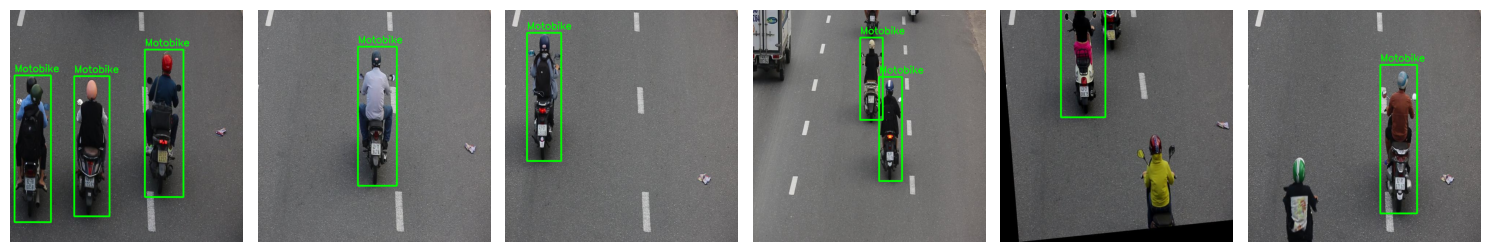

In [ ]:
import cv2
import matplotlib.pyplot as plt
import glob
import random

image_paths = glob.glob(f"{dataset_path}/train/images/*.jpg")

if len(image_paths) < 3:
    print(f"Warning: Not enough images found ({len(image_paths)}). Displaying all available images.")
    random_images = image_paths
elif len(image_paths) == 0:
    print("Error: No images found in the dataset directory. Please check DATASET_DIR.")
    random_images = []
else:
    random_images = random.sample(image_paths, 6)


plt.figure(figsize=(15, 10))

# Chỉ hiển thị nếu có ảnh để hiển thị
if random_images:
    for i, img_path in enumerate(random_images):
        # Đọc ảnh
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        height, width, _ = image.shape

        # Tìm file nhãn tương ứng (.txt)
        label_path = img_path.replace("images", "labels").replace(".jpg", ".txt")

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    # YOLO format: class x_center y_center width height (normalized)
                    class_id, x_c, y_c, w, h = map(float, line.split())

                    # Chuyển đổi tọa độ từ normalized sang pixel
                    x1 = int((x_c - w/2) * width)
                    y1 = int((y_c - h/2) * height)
                    x2 = int((x_c + w/2) * width)
                    y2 = int((y_c + h/2) * height)

                    # Vẽ khung bao lên ảnh
                    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 3)
                    cv2.putText(image, "Motobike", (x1, y1 - 10),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

        # Hiển thị
        plt.subplot(1, len(random_images), i + 1)
        plt.imshow(image)
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No images to display.")

In [ ]:
# Train mới hoàn toàn
!yolo task=detect mode=train \
model=yolov8s.pt \
data={dataset_path}/data.yaml \
epochs=75 imgsz=640 plots=True patience=50 batch=32 \
project={HOME}/runs/detect name=train

Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Motocycle_Detection_YOLOv8s/datasets/Motobike-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=75, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False

In [ ]:
!ls {HOME}/runs/detect/train2/weights

best.pt  last.pt


In [ ]:
#export your model's weights for future use
from google.colab import files
files.download(f'{HOME}/runs/detect/train2/weights/best.pt')
files.download(f'{HOME}/runs/detect/train2/weights/last.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

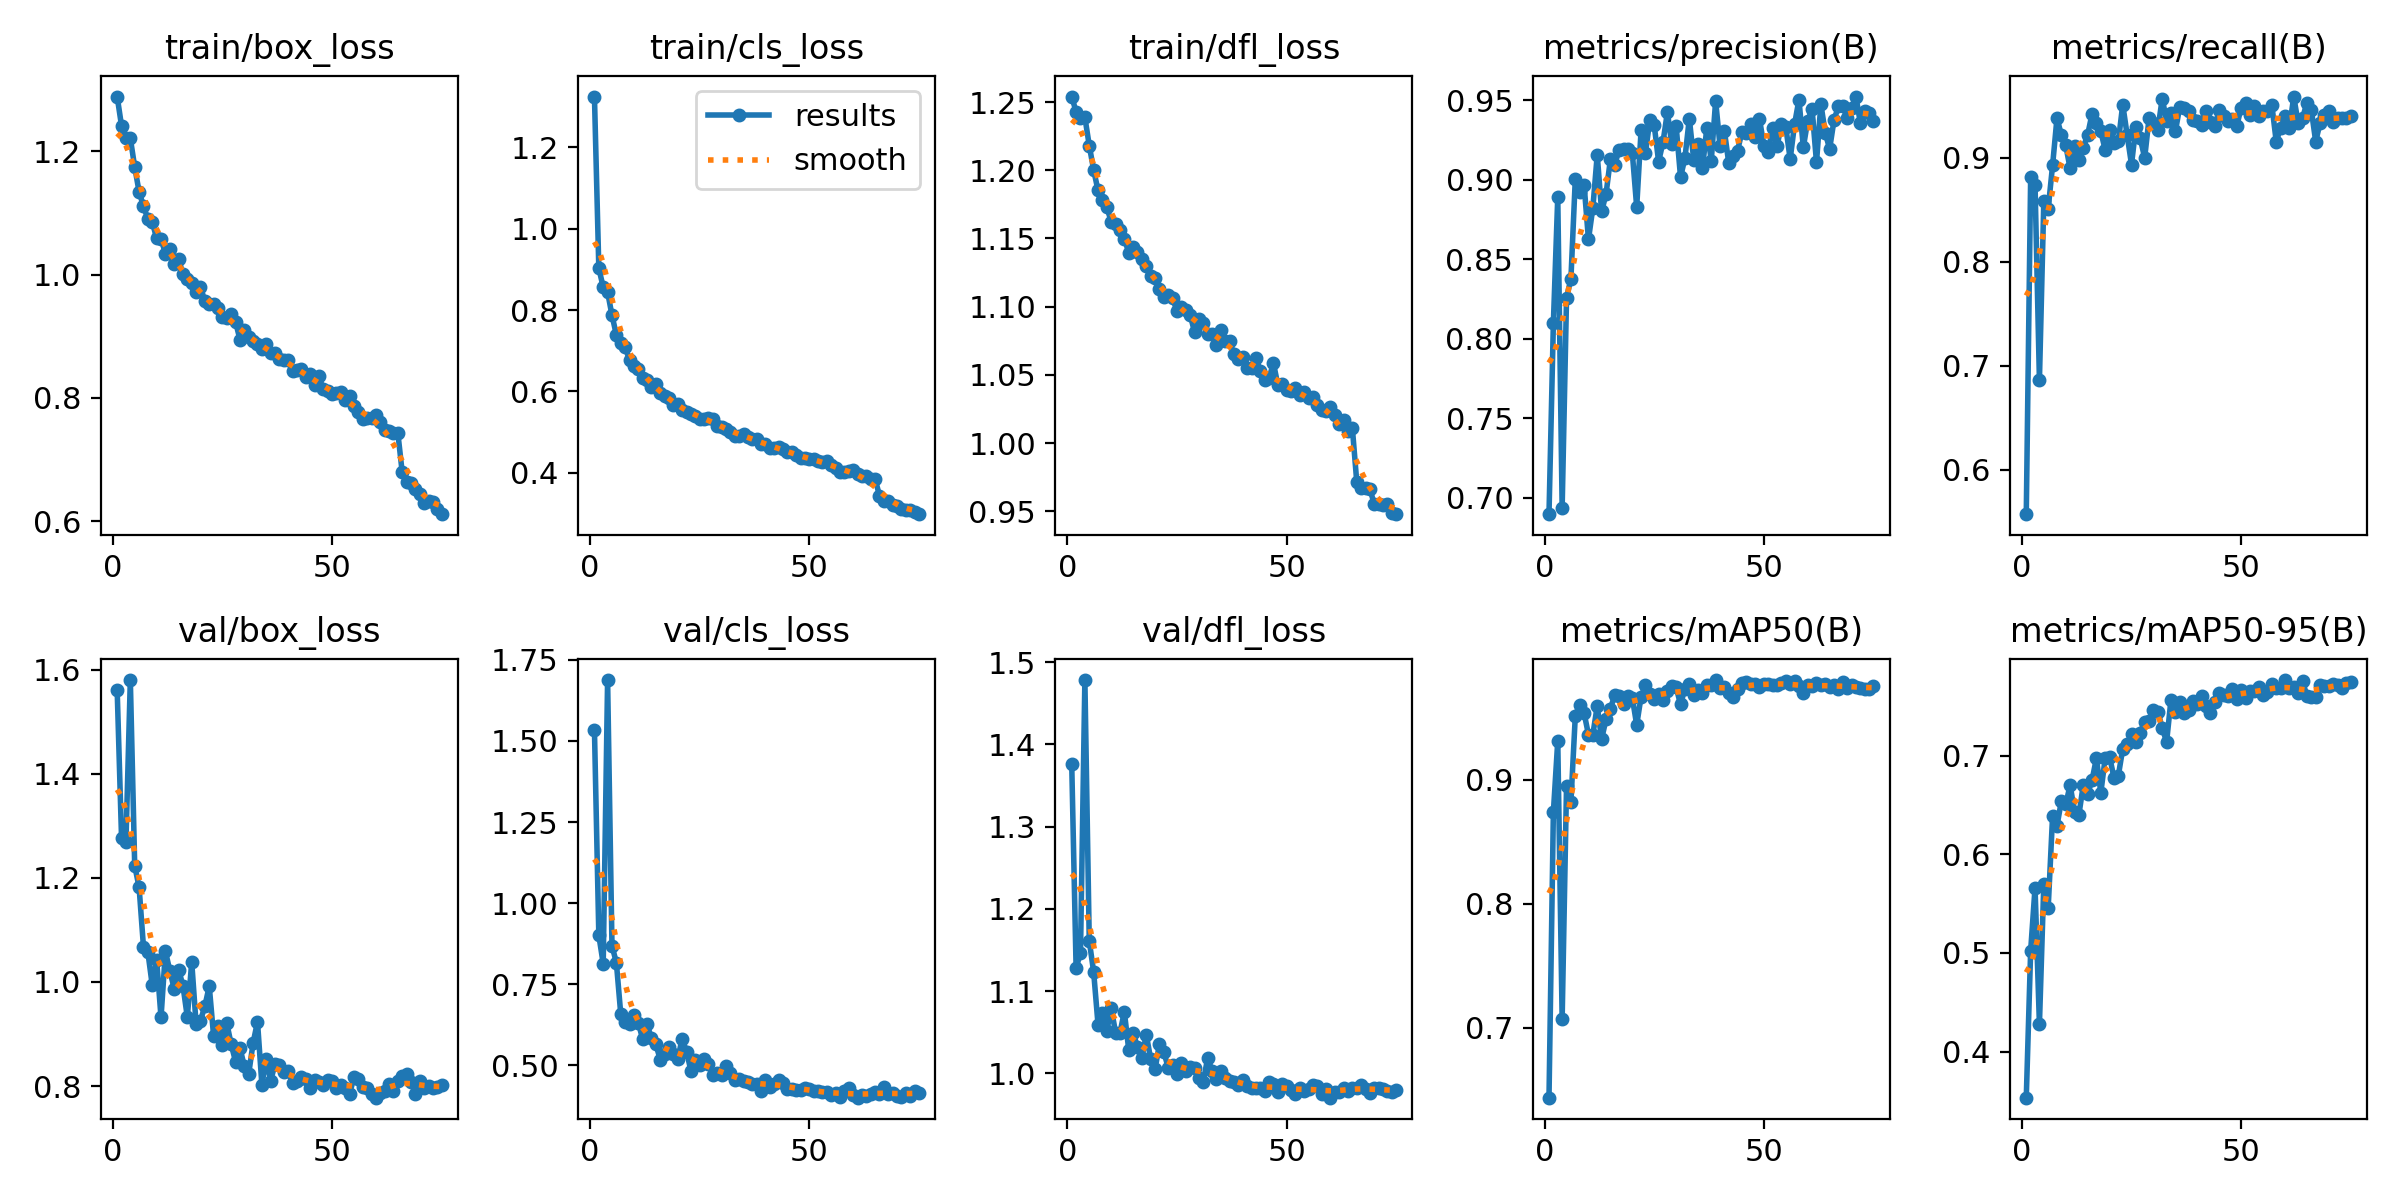

In [ ]:
from IPython.display import Image

Image(filename=f'{HOME}/runs/detect/train2/results.png', width=600)

In [ ]:
!yolo task=detect mode=val \
model={HOME}/runs/detect/train2/weights/best.pt \
data={dataset_path}/data.yaml \
imgsz=640

Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.3 ms, read: 36.1±5.8 MB/s, size: 58.9 KB)
val: Scanning /content/drive/MyDrive/Motocycle_Detection_YOLOv8s/datasets/Motobike-Detection-1/valid/labels.cache... 230 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 230/230 33.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 3.5it/s 4.3s
                   all        230        618      0.938       0.94      0.976      0.777
Speed: 2.2ms preprocess, 8.7ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /content/drive/MyDrive/Motocycle_Detection_YOLOv8s/runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


In [ ]:
!ls {HOME}/runs/detect/val

BoxF1_curve.png  confusion_matrix_normalized.png  val_batch1_labels.jpg
BoxP_curve.png	 confusion_matrix.png		  val_batch1_pred.jpg
BoxPR_curve.png  val_batch0_labels.jpg		  val_batch2_labels.jpg
BoxR_curve.png	 val_batch0_pred.jpg		  val_batch2_pred.jpg


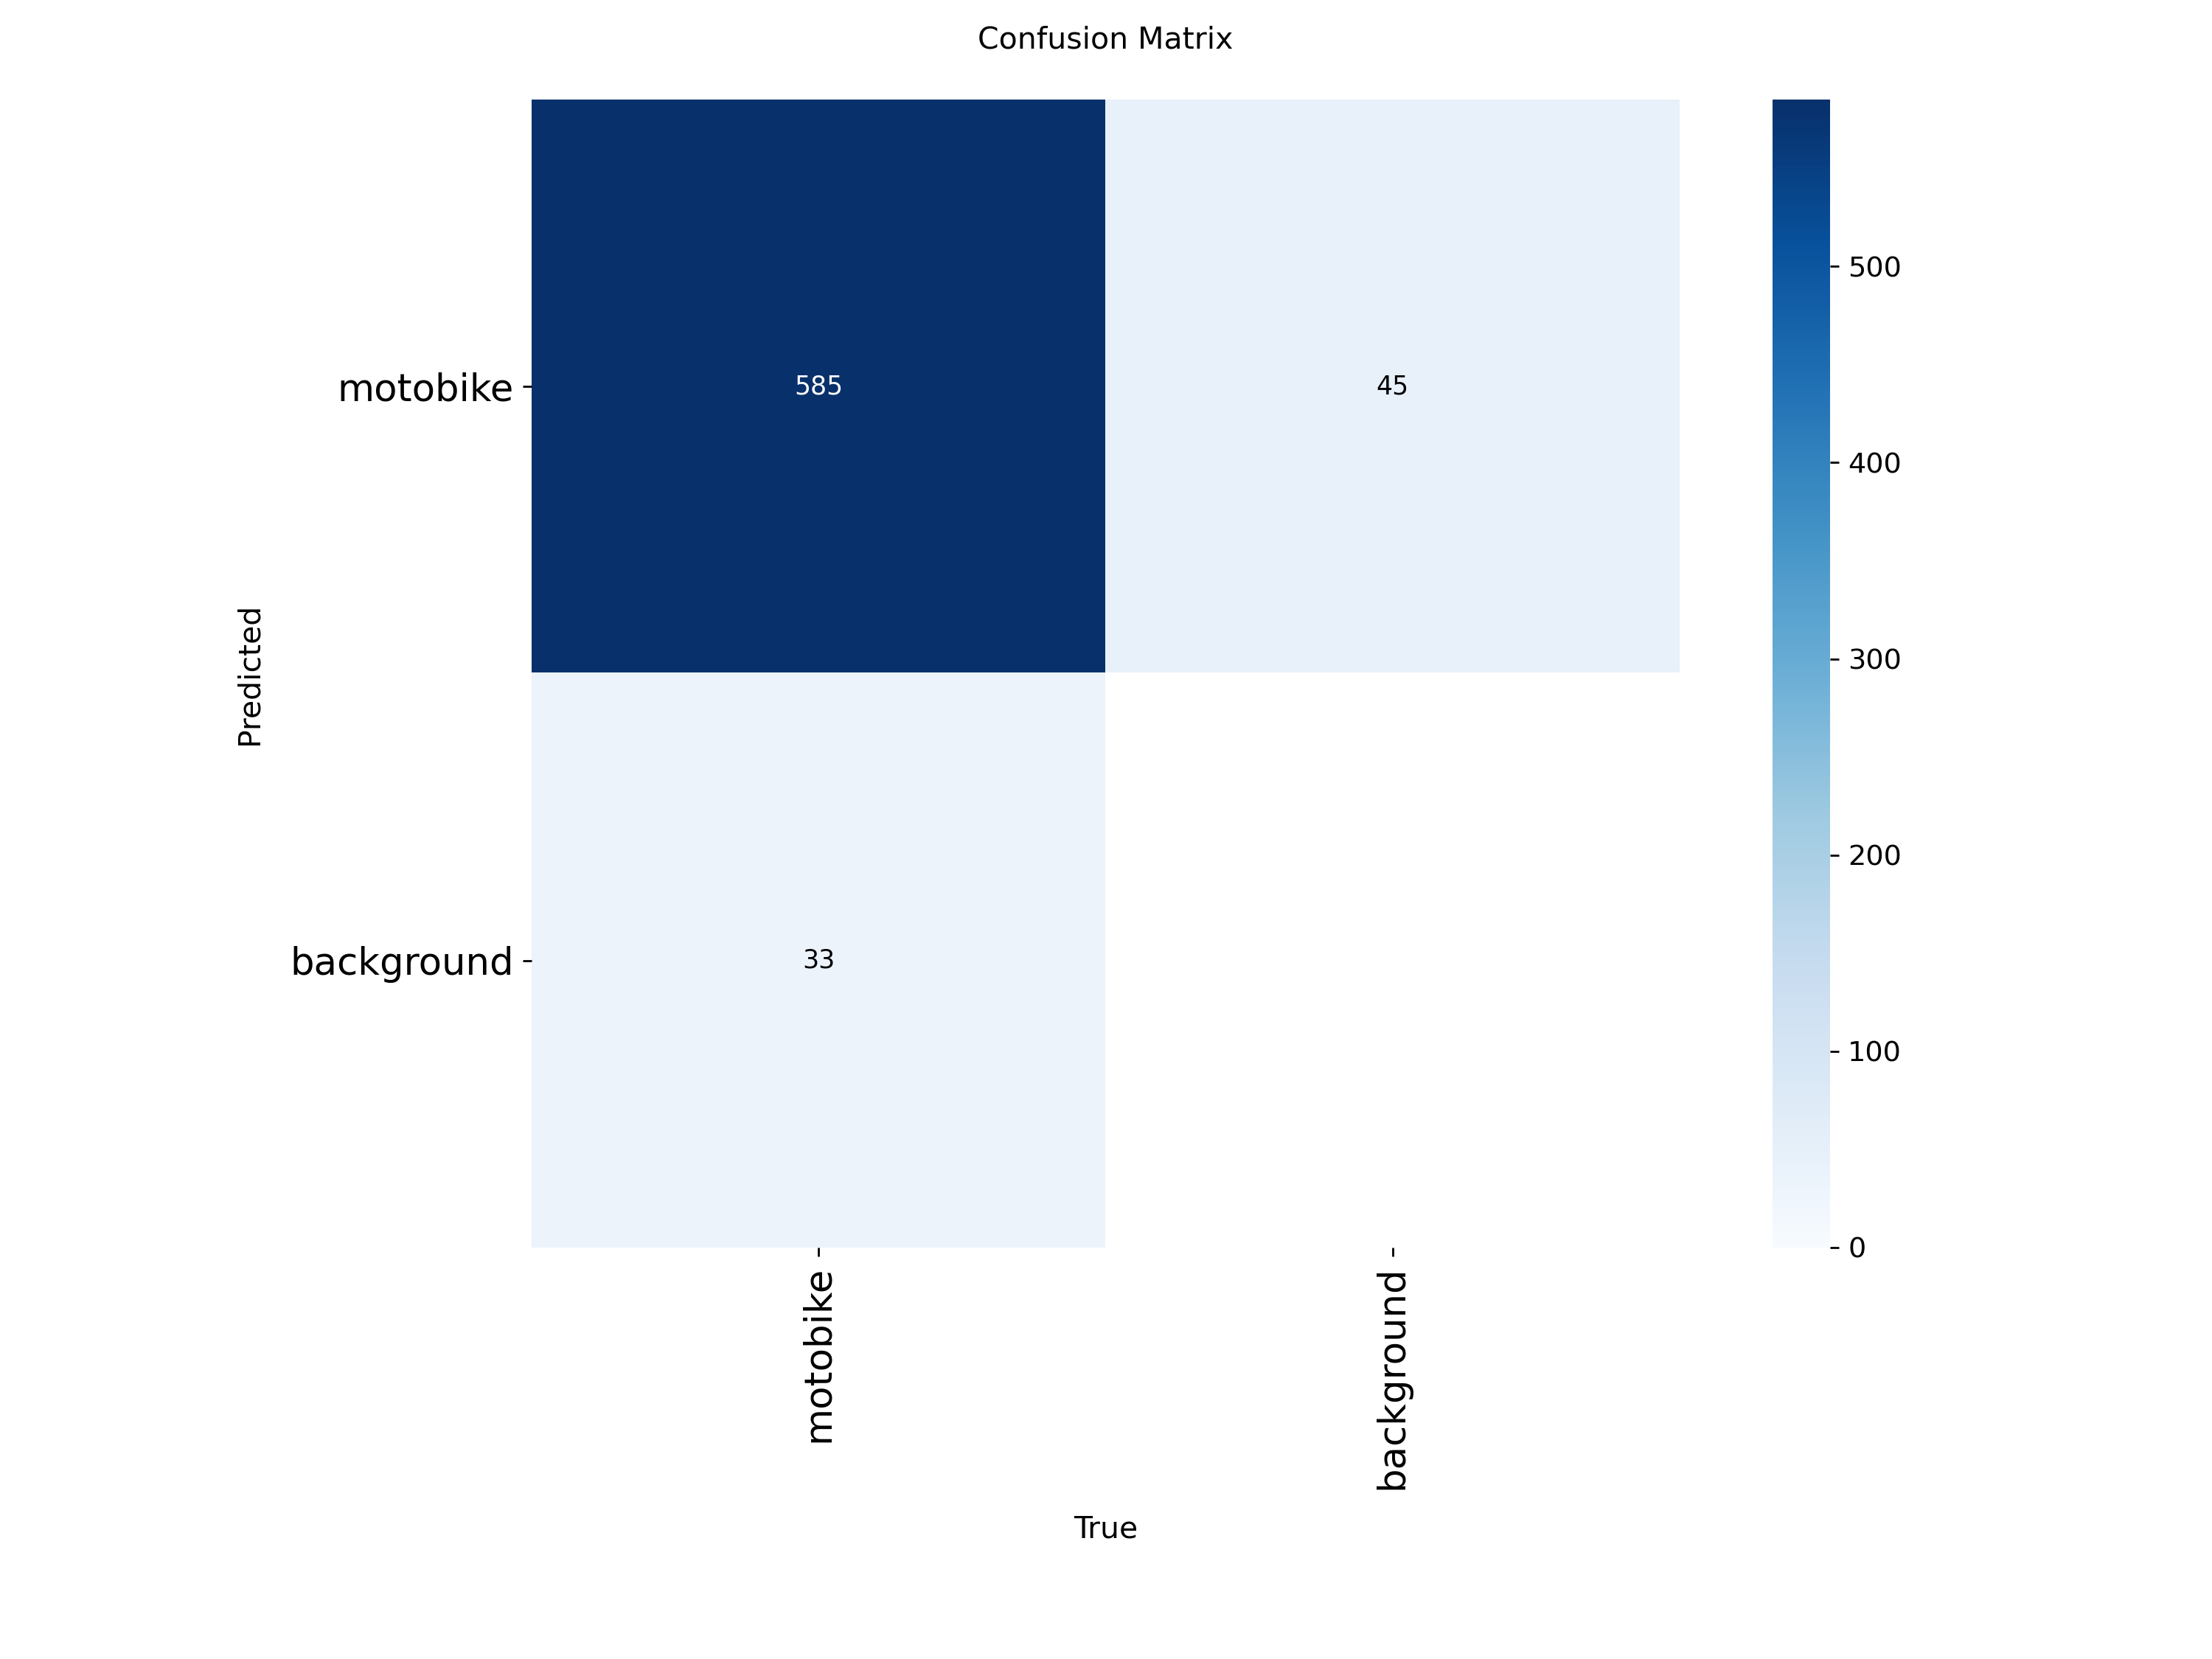

In [ ]:
Image(filename=f'{HOME}/runs/detect/val/confusion_matrix.png', width=600)

In [ ]:
!yolo task=detect mode=predict \
model={HOME}/runs/detect/train2/weights/best.pt \
source={dataset_path}/valid/images \
conf=0.25 \
save=True

Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs

image 1/230 /content/drive/MyDrive/Motocycle_Detection_YOLOv8s/datasets/Motobike-Detection-1/valid/images/3J4A7819_frame_0062_png_jpg.rf.d658b3724edc18fb9526601c978ff434.jpg: 640x640 3 motobikes, 16.2ms
image 2/230 /content/drive/MyDrive/Motocycle_Detection_YOLOv8s/datasets/Motobike-Detection-1/valid/images/3J4A7819_frame_0067_png_jpg.rf.10d1555e177ef115d3fdbeb3be40ebe4.jpg: 640x640 1 motobike, 16.2ms
image 3/230 /content/drive/MyDrive/Motocycle_Detection_YOLOv8s/datasets/Motobike-Detection-1/valid/images/3J4A7819_frame_0089_png_jpg.rf.16911fd385b947a14761caf4cc599674.jpg: 640x640 2 motobikes, 18.2ms
image 4/230 /content/drive/MyDrive/Motocycle_Detection_YOLOv8s/datasets/Motobike-Detection-1/valid/images/3J4A7819_frame_0092_png_jpg.rf.a7801a229d241779d6ab43c20eb7e603.jpg: 640x640 2 motobikes, 16.2ms
image 5/230 /content/dr

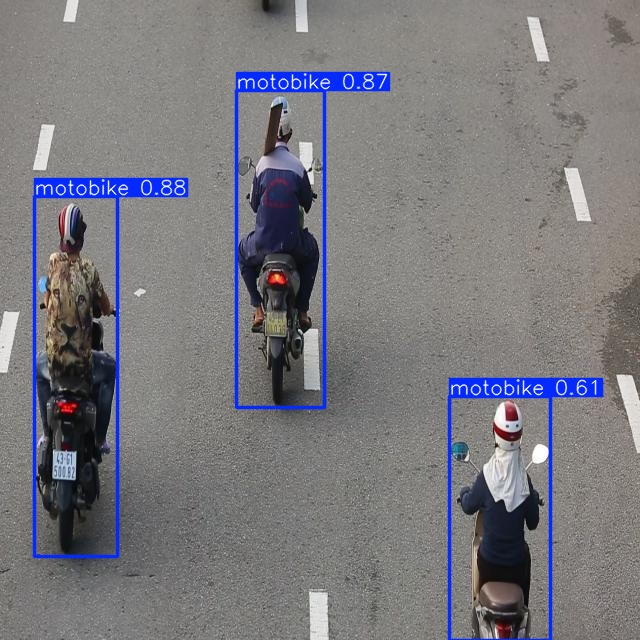

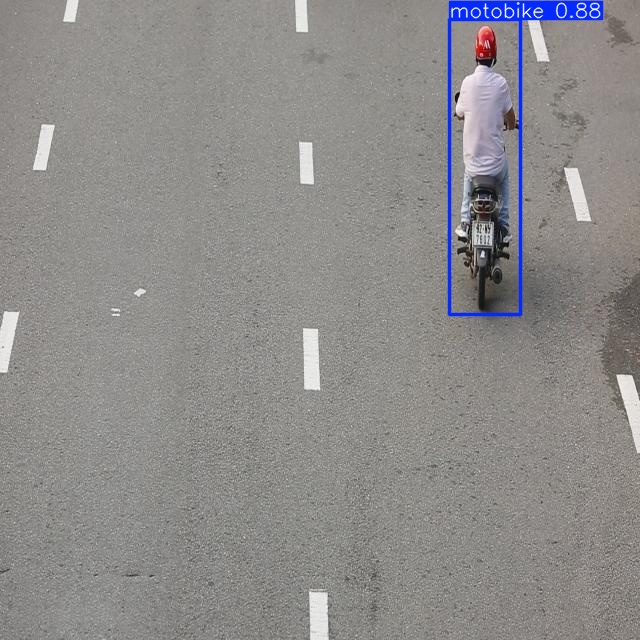

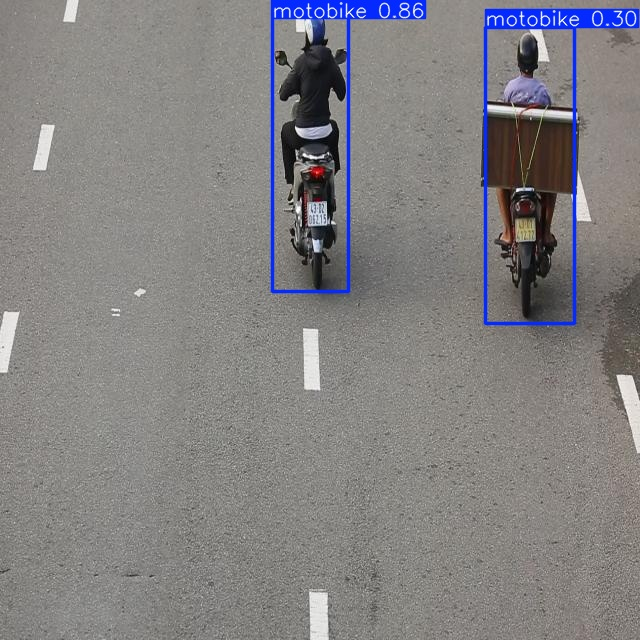

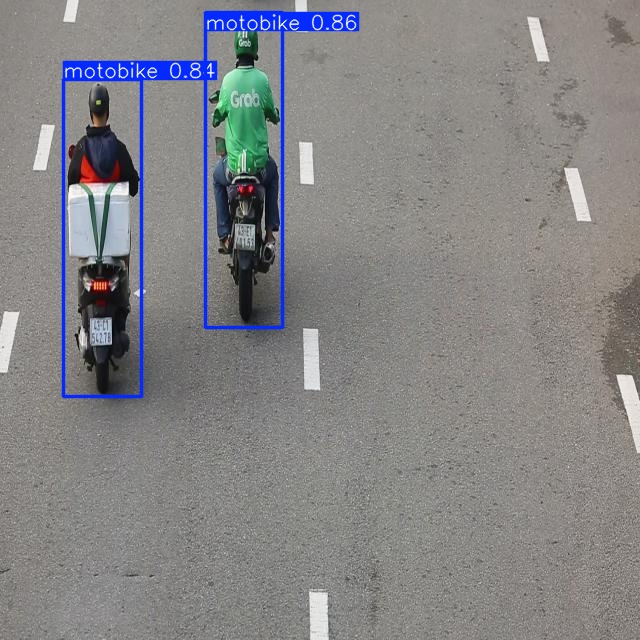

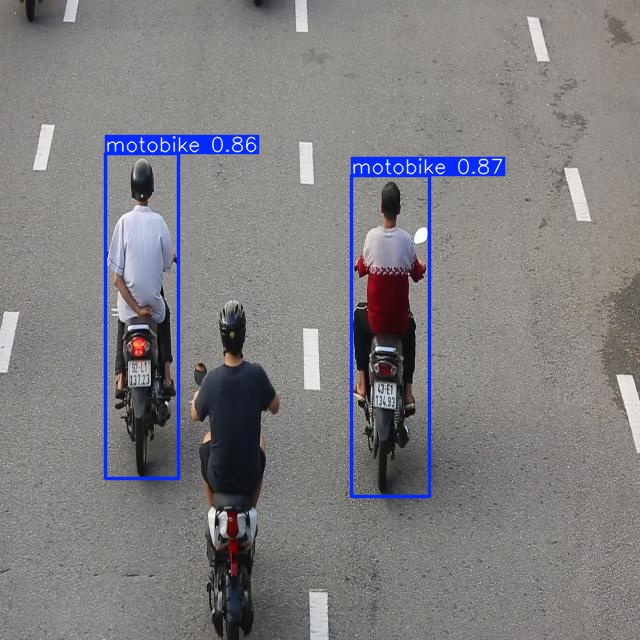

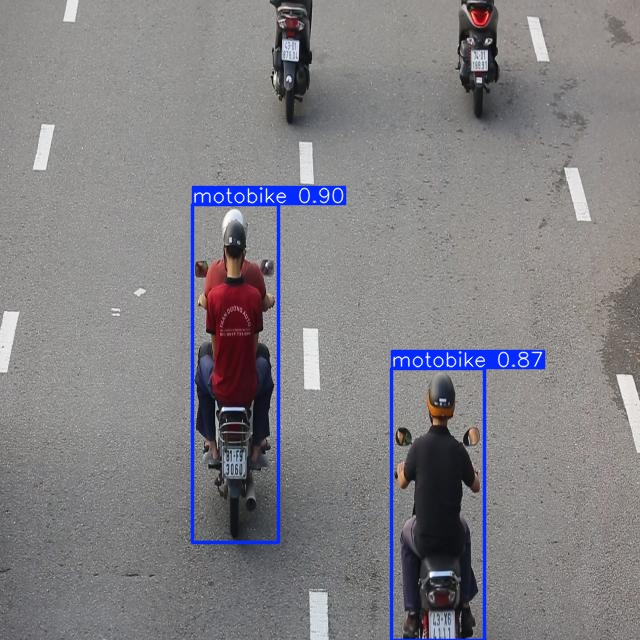

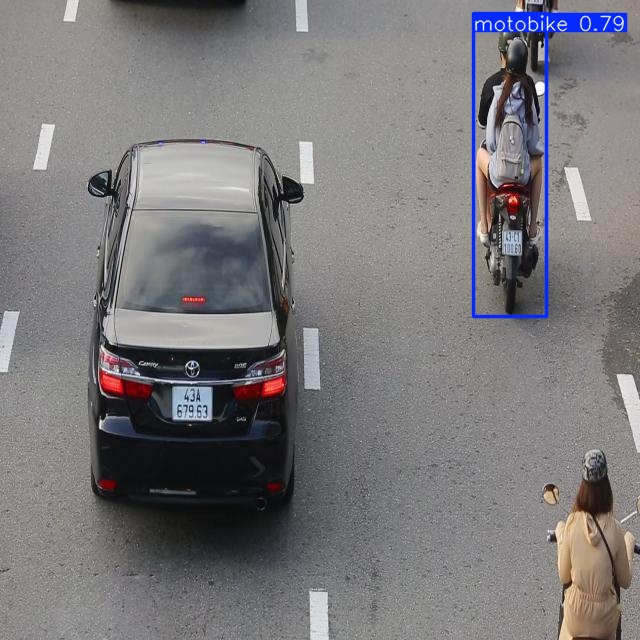

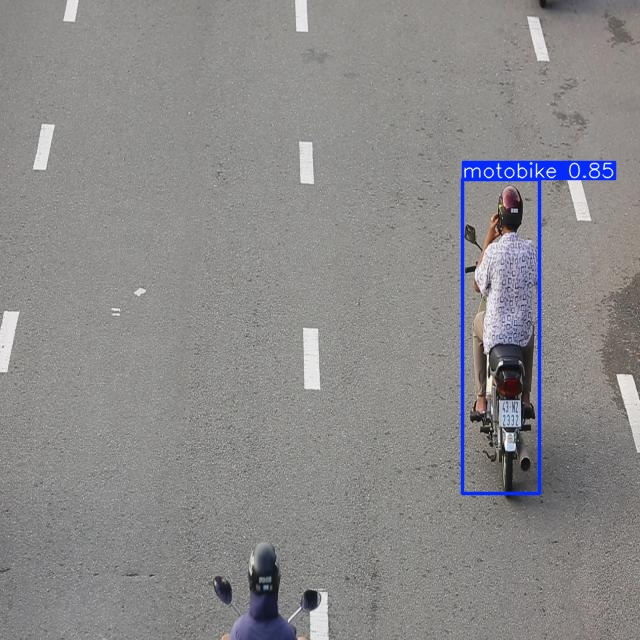

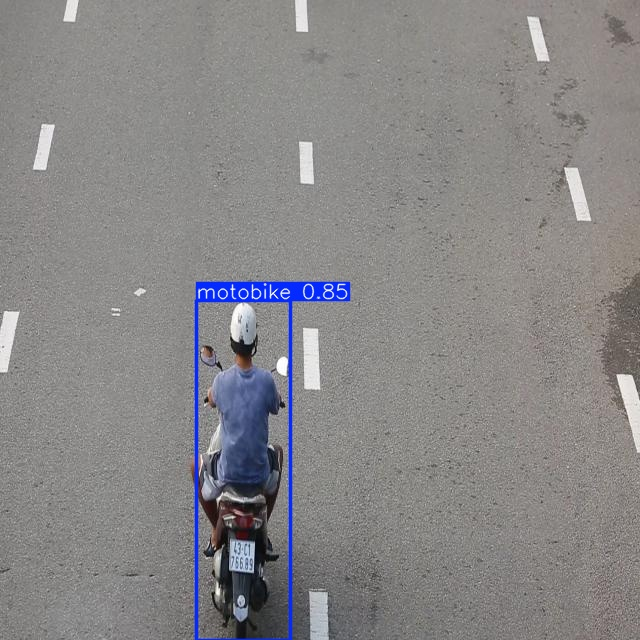

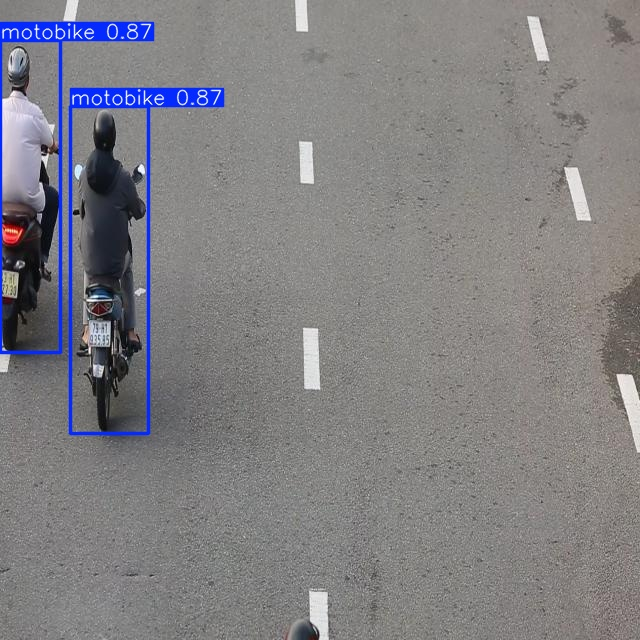

In [ ]:
from IPython.display import Image, display
import glob

images = glob.glob(f'{HOME}/runs/detect/predict/*.jpg')

for img in images[:10]:
    display(Image(filename=img))

In [ ]:
# from roboflow import Roboflow
# rf = Roboflow(api_key="CcdpH1yLdx3cnHIFjDRo")
# project = rf.workspace("vs-workspace-z80gy").project("motobike-detection-lqpwk")
# project.version(1).deploy(model_type="yolov8", model_path=f"{HOME}/runs/detect/train_motobike/")

In [ ]:
# # Resume lại từ checkpoint cuối cùng
# checkpoint_path = f"{HOME}/runs/detect/train_motobike/weights/last.pt"

# if os.path.exists(checkpoint_path):
#     !yolo task=detect mode=train resume=True model={checkpoint_path}
# else:
#     print("Không tìm thấy checkpoint để resume!")